# Clustering

Clustering analysis is valuable for documents because it groups similar texts based on their content, enabling efficient organization, exploration, and insight extraction from large, unstructured datasets.

Requirements: preprocessed datasets


Library installation

In [ ]:
!pip install ipympl -q

Import libraries

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

Some extra configuration to be able to plot

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

%matplotlib inline

Load the preprocessed dataset

In [ ]:
year = 2022
category = 'economics'

df = pd.read_csv(f'/content/sample_data/pravda_preprocessed_{year}_{category}.tsv', sep='\t')
df

,url,category,title,lead,paragraphs,lemmatized_paragraphs
0,https://www.pravda.ru/news/economics/1699757-gaz/,economics,"США наращивают объёмы производства СПГ, предвк...",Основную выгоду от отказа Европы отроссийского...,Основную выгоду от отказа Европы отроссийского...,основный выгода отказ европа отроссийского газ...
1,https://www.pravda.ru/news/economics/1714350-k...,economics,Китайское издание рассказало о победе России в...,Китайское издание Sina проанализировало меры р...,Китайское издание Sina проанализировало меры р...,китайский издание sina проанализировать мера р...
2,https://www.pravda.ru/news/economics/1706756-gaz/,economics,Медведев: бесплатная раздача газа приведёт Евр...,По словам зампреда Совбеза РФДмитрия Медведева...,По словам зампреда Совбеза РФДмитрия Медведева...,слово зампред совбез рфдмитрия медведев готовн...
3,https://www.pravda.ru/news/economics/1693541-gaz/,economics,"Politico: Байден ""провалил"" своё обещание спас...","Лидер СШАДжо Байденпообещал спасти Европу, осв...","Лидер СШАДжо Байденпообещал спасти Европу, осв...",лидер сшаджо байденпообещал спасти европа осво...
4,https://www.pravda.ru/news/economics/1709244-r...,economics,На заводах Renault шесть лет ничего нельзя мен...,"К производствуэлектромобилей, а также внедрени...","К производствуэлектромобилей, а также внедрени...",производствуэлектромобилей внедрение изменение...
...,...,...,...,...,...,...
1756,https://www.pravda.ru/economics/1712723-default/,economics,"""Хуже 1998-го не будет"": чем россиянам грозит ...","Как и обещали (пугали) власти США, 25 мая амер...","Как и обещали (пугали) власти США, 25 мая амер...",обещать пугать власть сша 25 май американский ...
1757,https://www.pravda.ru/news/economics/1729538-s...,economics,"В США рассказали о ""секретном грузе"" из России...",Американские власти держали в секрете информац...,Американские власти держали в секрете информац...,американский власть держать секрет информация ...
1758,https://www.pravda.ru/news/economics/1774674-o...,economics,Ниже 82 долларов: в ОПЕК обеспокоены снижением...,В ОПЕК обеспокоены падениемстоимости на нефть....,В ОПЕК обеспокоены падениемстоимости на нефть....,опек обеспокоить падениемстоимости нефть внешн...
1759,https://www.pravda.ru/news/economics/1677299-n...,economics,Нефть марки Brent продолжает дорожать из-за вы...,На понедельничных торгах ценамартовских фьючер...,На понедельничных торгах ценамартовских фьючер...,понедельничный торг ценамартовских фьючерсовна...


Get a list of documents

In [ ]:
documents = df['lemmatized_paragraphs'].tolist()

Access document by index

In [ ]:
documents[0]

'основный выгода отказ европа отроссийского газаполучают компания сша заниматься экспорт сжидить природный газ спг напоминаетfinancial times соединённым штат принадлежать мировой лидерство производство спг суммарный годовой объём производство газ 120 миллиард кубометр сша планировать наращивать производственный мощность открывать три новый завод производство спг давать 70 миллиард кубометр газ мнение аналитик ft \xa0 сша получить желаемый выгода отказ ес российский газ отрицательно сказаться сторона отрасль цена газ развитие инфраструктура производство спг усилие мировой сообщество переход зелёный экономика слово бывший министр энергетика сшадэна бруйетта европа склонный положительно рассматривать американский спг альтернатива российский газ европеец понимать возобновлять источник энергия недостаточный рамка антироссийский санкция связать спецоперация украина запад призывать ес отказаться российский газ несмотря понимать заменить энергоресурсы рф момент'

Create the document-term matrix using TF-IDF

In [ ]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 199341 stored elements and shape (1761, 26439)>

Reduce dimensionality to 2D using Principal Component Analysis (PCA)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_matrix = pca.fit_transform(tfidf_matrix)

Apply K-Means clustering

In [ ]:
n_clusters = 3  # Number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pca_matrix)

Plot the 2D representation with clusters

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


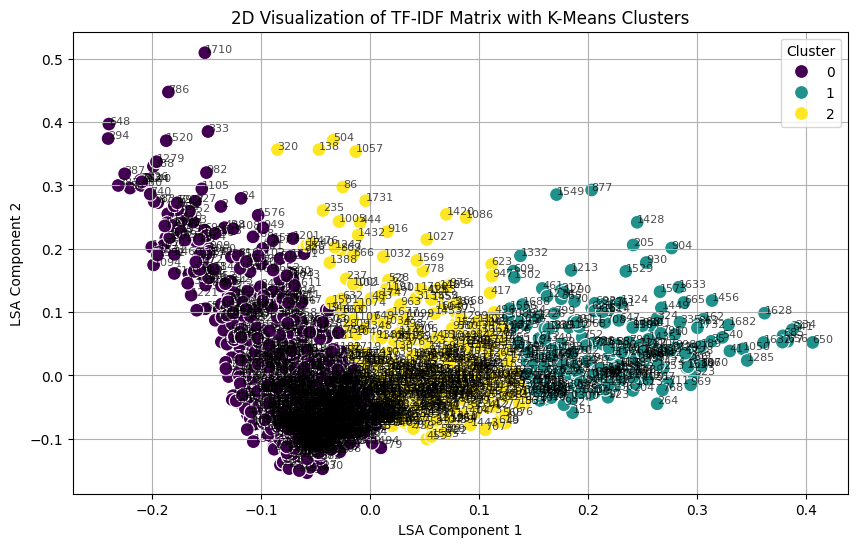

In [ ]:
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=pca_matrix[:, 0],
    y=pca_matrix[:, 1],
    hue=cluster_labels,
    palette='viridis',
    s=100,
    legend='full'
)

# Add document index as label
for i, txt in enumerate([f"{i+1}" for i in range(len(documents))]):
    plt.annotate(txt, (pca_matrix[i, 0], pca_matrix[i, 1]), fontsize=8, alpha=0.7)

# Customize the plot
plt.title('2D Visualization of TF-IDF Matrix with K-Means Clusters')
plt.xlabel('LSA Component 1')
plt.ylabel('LSA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

You can check the documents by index for reference

In [ ]:
documents[156]

'вице премьер рфалександр новакотметил кризисный ситуация житель европейский государство вынуждены прибегать несовременный источник энергия говорить план государство евросоюз скорый отказ поставка энергоресурсы россия вице премьер отметить сделать сложный слово александр новака европа отсутствовать необходимый инфраструктура приём сжидить природный газ быстро нарастить поставка спг объём российский газ европейский рынок прошлый год превысить порядок 156 млрд кубометр десять лишний раз объём заявить сша(для поставка год ред стоимость сжидить газ значительно высоко трубопроводный россия немаловажный оставаться фактор надёжность помнить прошлый осень высокий цена азиатский рынок европа недосчитаться существенный объёма спг написать новак статья опубликовать журнал энергетический политика вице премьер обратить внимание аспект слово снизить зависимость российский уголь европа пытаться помощь уголь стремительный возврат угольный генерация происходить фон заявление страна ес декарбонизация эк

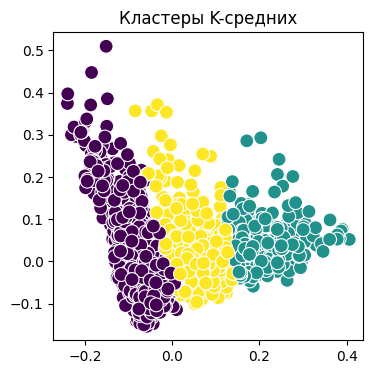

In [ ]:
plt.figure(figsize=(4, 4))
scatter = sns.scatterplot(
    x=pca_matrix[:, 0],
    y=pca_matrix[:, 1],
    hue=cluster_labels,
    palette='viridis',
    s=100,
    legend=False
)

# Customize the plot
plt.title('Кластеры K-средних')
plt.show()